In [ ]:
import torch
from torchvision import models
import torchvision.transforms.functional as transform
import PIL
import os
from tqdm import tqdm
import json
import numpy as np
from torch import nn

In [ ]:
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

# model = torch.load('my_model.pt')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 160MB/s]


In [ ]:
import torch
import torch.nn as nn

# Загрузка первоначальной модели с предобученными весами
model = torch.hub.load("chenyaofo/pytorch-cifar-models", 'cifar100_resnet20', pretrained=True)

# Измените количество классов в выходном слое
num_classes = 31  # Количество классов в вашей задаче

# Замена верхнего слоя (fc)
in_features = model.fc.in_features  # Получаем количество входных признаков для полносвязного слоя
model.fc = nn.Linear(in_features=in_features, out_features=num_classes, bias=True)

# Загрузка state_dict из файла
state_dict = torch.load('my_model.pth')

# Создание нового state_dict для загрузки
new_state_dict = {}
for key, value in state_dict.items():
    if key.startswith('1.'):
        new_key = key[2:]  # Убираем "1." только если он в начале
    else:
        new_key = key

    # Оставляем только те ключи, которые соответствуют размеру модели
    if new_key in model.state_dict() and value.size() == model.state_dict()[new_key].size():
        new_state_dict[new_key] = value

# Загрузка нового state_dict в модель
model.load_state_dict(new_state_dict, strict=False)  # Используйте strict=False, чтобы игнорировать отсутствующие ключи

# model.eval()  # Перевод в режим оценки

# Перевод модели на нужное устройство (CPU или GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Теперь вы можете вывести архитектуру
print(model)


/usr/local/lib/python3.11/dist-packages/torch/hub.py:330: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to {calling_fn}(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  warnings.warn(
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/resnet/cifar100_resnet20-23dac2f1.pt" to /root/.cache/torch/hub/checkpoints/cifar100_resnet20-23dac2f1.pt
100%|██████████| 1.11M/1.11M [00:00<00:00, 13.8MB

CifarResNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias

In [ ]:
# у него дал самый последний слой на 100 классов
model.fc

Linear(in_features=64, out_features=31, bias=True)

In [ ]:
# тождественное преобразование
class Identify(torch.nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    return x

model.fc = Identify()

In [ ]:
import torchvision.transforms as transforms
from PIL import Image

#preprocess = weights.transforms()


height_width = 32
preprocess = transforms.Compose([
    transforms.Resize((height_width, height_width), interpolation=Image.LANCZOS),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5074, 0.4867, 0.4411], std=[0.2011, 0.1987, 0.2025])
])

In [ ]:


img_path = './content/pics'
PIL_img = Image.open(img_path).convert('RGB')
# new_PIL_img = transform.to_pil_image(tensor_img)

FileNotFoundError: [Errno 2] No such file or directory: './content/pics'

In [ ]:
pil_img = Image.open("/content/pics/Вербена прерийная.jpeg").convert('RGB')

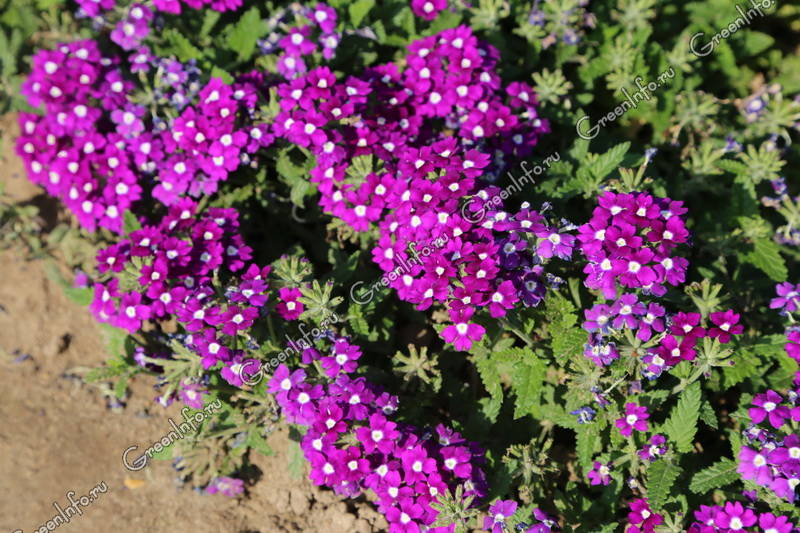

In [ ]:
pil_img

In [ ]:
# img = transform.to_tensor(pil_img)

In [ ]:
pil_img.shape # 3.224.224

AttributeError: 'Image' object has no attribute 'shape'

In [ ]:
img_transformed = preprocess(pil_img)
img_transformed.shape

torch.Size([3, 32, 32])

In [ ]:
# модель -  врежим вычисления, а не обучения
model.eval()

CifarResNet(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias

In [ ]:
# картинку - в батч
batch_img = img_transformed.unsqueeze(0)
batch_img.shape # 1.3.224.224

torch.Size([1, 3, 32, 32])

In [ ]:
with torch.no_grad():
  prediction = model(batch_img)

prediction.shape # [1, N] -массив

torch.Size([1, 64])

In [ ]:
files = os.listdir('./pics')
len(files)

12

In [ ]:
imgs = []

for f in tqdm(files):
  pil_img = PIL.Image.open(f'./pics/{f}').convert('RGB')
  # img = transform.to_tensor(pil_img)
  img_transformed = preprocess(pil_img)
  imgs.append(img_transformed)

100%|██████████| 12/12 [00:00<00:00, 49.98it/s]


In [ ]:
len(imgs)

12

In [ ]:
index = []
for f in files:
  index.append(f.split('.')[0])

with open('index.json', 'w') as f:
  json.dump(index, f)

In [ ]:
index[9]

'Космея _Конфетная Полоска_'

In [ ]:
imgs[0].shape #3.224.224

torch.Size([3, 32, 32])

In [ ]:
imgs[0].unsqueeze(0).shape #1,3.224.224

torch.Size([1, 3, 32, 32])

In [ ]:
batch = torch.vstack(tuple((im.unsqueeze(0) for im in imgs)))

batch.shape # N.3.224.224

torch.Size([12, 3, 32, 32])

In [ ]:
%%time

with torch.no_grad():
  vects = model(batch)

vects.shape # torch.size(N, 2048)

CPU times: user 38.7 ms, sys: 0 ns, total: 38.7 ms
Wall time: 37.9 ms


torch.Size([12, 64])

In [ ]:
vects_norm = vects / torch.Tensor.repeat(vects.norm(dim=1).unsqueeze(1), 1, 64)
vects_norm_np = vects_norm.numpy()

In [ ]:
np.min(vects_norm_np)

0.0006326206

In [ ]:
np.max(vects_norm_np)

0.38968983

In [ ]:
with open('./vects.npy', 'wb') as f:
  np.save(f, vects_norm_np)

In [ ]:
vects_norm_np = vects_norm_np.astype(np.float16)
vects_norm_np_q = vects_norm_np * 128
vects_norm_np_q = vects_norm_np_q.astype(np.int8)

with open('./vects_q.npy', 'wb') as f:
  np.save(f, vects_norm_np_q)

## дальше - рекомендашки

In [ ]:
with open('./vects_q.npy', 'rb') as f:
  vects = np.load(f)

with open('./index.json', 'rb') as f:
  index = json.load(f)

In [ ]:
def get_similar(v, vects, n=10):
  scores = np.matmul(vects, v)
  scores = scores / 128
  top_similat_ind = (-scores).argsort()[:n]
  return {
      'similar_ind': list(top_similat_ind),
      'similar_scores': list(scores[top_similat_ind])
  }

In [ ]:
def get_by_indexs(inds, index):
  f_names = []
  for i in inds:
    f_names.append(f'/pics/{index[i]}_0.jpg')
  return f_names

In [ ]:
def get_sim_mean(viewed_ids, vects, n=10):
  v = np.zeros(64)
  viewed_ids = viewed_ids[::-1][:10]
  for i in viewed_ids[:]:
    v += vects[i]
  v /= len(viewed_ids)
  v /= np.linalg.norm(v)
  return filter_(get_similar(v, vects, n+len(viewed_ids)), viewed_ids)


In [ ]:
def filter_(recs, viewed_ids):
  res = {
      'similar_ind': [],
      'similar_scores': []
  }
  for i in range(len(recs['similar_ind'])):
    if recs['similar_ind'][i] not in viewed_ids:
      res['similar_ind'].append(recs['similar_ind'][i])
      res['similar_scores'].append(recs['similar_scores'][i])
  return res

In [ ]:
class NpEncoder(json.JSONEncoder):
  def default(self, obj):
    if isinstance(obj, np.integer):
      return int(obj)
    if isinstance(obj, np.floating):
      return float(obj)
    if isinstance(obj, np.ndarray):
      return obj.tolist()
    return super(NpEncoder, self).default(obj)


In [ ]:
viewed_ids = [1, 4]

In [ ]:
res = get_sim_mean(viewed_ids, vects)

In [ ]:
for i in range(len(index)):
  print(i, index[i])

0 Вербена прерийная
1 Вербена сиреневая
2 Гиацинт _Фондант_
3 Бархатцы французские
4 Вербена Королевский Красный
5 Космея _Соната Кармин_
6 Гиацинт _Голубая Звезда_
7 Бархатцы _Легион Чести_
8 Гиацинт махровый
9 Космея _Конфетная Полоска_
10 Вербена персиковая
11 Гиацинт голландский


In [ ]:
res['similar_ind']

[0, 10, 9, 5, 6, 8, 3, 11, 7, 2]

In [ ]:
res['similar_scores']

[0.8474569761433615,
 0.831746955961264,
 0.8116163673296586,
 0.7959403515202497,
 0.7884253851560861,
 0.7873712496027421,
 0.7740755398815296,
 0.7329302489284173,
 0.7112014547804512,
 0.7082430743565498]

In [ ]:
file_names = get_by_indexs(res['similar_ind'], index)

# Теперь file_names будет содержать соответствующие названия
print(file_names)

['/pics/Вербена прерийная_0.jpg', '/pics/Вербена персиковая_0.jpg', '/pics/Космея _Конфетная Полоска__0.jpg', '/pics/Космея _Соната Кармин__0.jpg', '/pics/Гиацинт _Голубая Звезда__0.jpg', '/pics/Гиацинт махровый_0.jpg', '/pics/Бархатцы французские_0.jpg', '/pics/Гиацинт голландский_0.jpg', '/pics/Бархатцы _Легион Чести__0.jpg', '/pics/Гиацинт _Фондант__0.jpg']


In [ ]:
json.dumps(res, cls=NpEncoder)

'{"similar_ind": [0, 9, 6, 5, 4, 11, 10, 3, 8, 2], "similar_scores": [0.7831383533465919, 0.7356811070240319, 0.7200496029652177, 0.682596519240299, 0.6757811834706557, 0.6677778533925429, 0.6647140785970154, 0.6486448924245544, 0.6094410802450484, 0.5948099924459983]}'